# Ödev 2 — MLE ile Akıllı Şehir Planlaması

**Ders:** YZM212 Makine Öğrenmesi · 2. Laboratuvar Ödevi  
**Yöntem:** Maximum Likelihood Estimation (MLE) — Poisson Dağılımı

**Senaryo:** Şehrin en yoğun caddesinden bir dakikada geçen araç sayısı Poisson dağılımına uyuyor. MLE ile en iyi λ parametresini tahmin edeceğiz.

---
## Bölüm 1: Teorik Türetme (Analitik Çözüm)

Poisson dağılımı:
$$P(k \mid \lambda) = \frac{e^{-\lambda} \cdot \lambda^k}{k!}$$

### 1.1. Likelihood Fonksiyonu

n bağımsız gözlem $\{k_1, k_2, \ldots, k_n\}$ için:

$$L(\lambda) = \prod_{i=1}^{n} \frac{e^{-\lambda}\,\lambda^{k_i}}{k_i!} = e^{-n\lambda}\;\lambda^{\sum k_i}\;\prod_{i=1}^{n}\frac{1}{k_i!}$$

### 1.2. Log-Likelihood Fonksiyonu

$$\ell(\lambda) = \ln L(\lambda) = \sum_{i=1}^{n}\left(-\lambda + k_i\ln\lambda - \ln k_i!\right) = -n\lambda + \left(\sum_{i=1}^{n} k_i\right)\ln\lambda - \sum_{i=1}^{n}\ln k_i!$$

### 1.3. MLE Tahmini — Türev Sıfıra Eşitleme

$$\frac{d\ell}{d\lambda} = -n + \frac{\displaystyle\sum_{i=1}^{n} k_i}{\lambda} = 0$$

$$\boxed{\hat{\lambda}_{\text{MLE}} = \frac{\sum_{i=1}^{n} k_i}{n} = \bar{k}}$$

> **Sonuç:** Poisson dağılımı için MLE tahmini, gözlemlerin **aritmetik ortalamasına** eşittir.

---
## Bölüm 2: Python ile Sayısal MLE

In [1]:
import numpy as np
import scipy.optimize as opt
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from pathlib import Path

REPORT_DIR = Path('..') / 'report'
REPORT_DIR.mkdir(exist_ok=True)

# Gözlemlenen Trafik Verisi (1 dakikada geçen araç sayısı)
traffic_data = np.array([12, 15, 10, 8, 14, 11, 13, 16, 9, 12, 11, 14, 10, 15])

print(f'Veri: {traffic_data}')
print(f'n = {len(traffic_data)}, Ortalama = {np.mean(traffic_data):.4f}, '
      f'Min = {traffic_data.min()}, Max = {traffic_data.max()}')


Veri: [12 15 10  8 14 11 13 16  9 12 11 14 10 15]
n = 14, Ortalama = 12.1429, Min = 8, Max = 16


In [2]:
def negative_log_likelihood(lam, data):
    """
    Poisson dagilimi icin Negatif Log-Likelihood hesaplar.
    NLL = n*lambda - sum(k_i)*log(lambda)   [log(k!) sabiti ihmal edildi]
    """
    lam = lam[0]  # scipy minimize 1-D array gecirir
    if lam <= 0:
        return np.inf
    n = len(data)
    # Log-likelihood: -n*lambda + sum(k)*ln(lambda)  -> negatife cevir
    nll = n * lam - np.sum(data) * np.log(lam)
    return nll

# Scipy ile optimizasyon (NLL minimize = Likelihood maximize)
initial_guess = [1.0]
result = opt.minimize(
    negative_log_likelihood,
    initial_guess,
    args=(traffic_data,),
    bounds=[(0.001, None)]
)

lambda_mle      = result.x[0]
lambda_analytic = np.mean(traffic_data)

print(f'Sayisal Tahmin  (scipy MLE) : lambda = {lambda_mle:.6f}')
print(f'Analitik Tahmin (Ortalama)  : lambda = {lambda_analytic:.6f}')
print(f'Fark: {abs(lambda_mle - lambda_analytic):.2e}  -> Pratik olarak ayni')


Sayisal Tahmin  (scipy MLE) : lambda = 12.142851
Analitik Tahmin (Ortalama)  : lambda = 12.142857
Fark: 6.53e-06  -> Pratik olarak ayni


---
## Bölüm 3: Model Karşılaştırma ve Görselleştirme

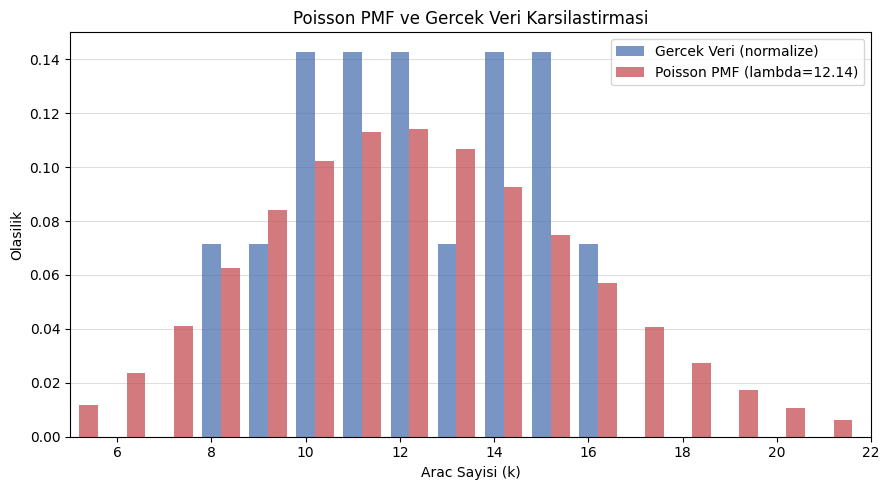

Yorum: Poisson PMF, gercek veri dagilimiyla iyi ortusüyor.
Verinin 8-16 araligina yogunlastigi ve modelin bu bicimi basariyla yakaladigi gorülüyor.


In [3]:
# PMF icin k araligi
k_vals  = np.arange(0, 30)
pmf_vals = stats.poisson.pmf(k_vals, mu=lambda_mle)

fig, ax = plt.subplots(figsize=(9, 5))

# Histogram: her benzersiz degerin goreli frekansi
unique, counts = np.unique(traffic_data, return_counts=True)
ax.bar(unique, counts / len(traffic_data), width=0.4,
       color='#4C72B0', alpha=0.75, label='Gercek Veri (normalize)', zorder=2)

# Poisson PMF
ax.bar(k_vals + 0.4, pmf_vals, width=0.4,
       color='#C44E52', alpha=0.75,
       label=f'Poisson PMF (lambda={lambda_mle:.2f})', zorder=2)

ax.set_xlabel('Arac Sayisi (k)')
ax.set_ylabel('Olasilik')
ax.set_title('Poisson PMF ve Gercek Veri Karsilastirmasi')
ax.set_xlim(5, 22)
ax.legend()
ax.grid(axis='y', alpha=0.4)
fig.tight_layout()
fig.savefig(REPORT_DIR / 'pmf_histogram.png', dpi=140)
plt.show()

print('Yorum: Poisson PMF, gercek veri dagilimiyla iyi ortusüyor.\n'
      'Verinin 8-16 araligina yogunlastigi ve modelin bu bicimi basariyla yakaladigi gorülüyor.')


---
## Bölüm 4: Gerçek Hayat Senaryosu — Outlier Analizi

Veri setine yanlışlıkla `200` araçlık hatalı bir gözlem ekleniyor. MLE bu aykırı değerden nasıl etkileniyor?

In [4]:
# Aykirn degerli veri seti
traffic_with_outlier = np.append(traffic_data, 200)

result_outlier = opt.minimize(
    negative_log_likelihood,
    [1.0],
    args=(traffic_with_outlier,),
    bounds=[(0.001, None)]
)
lambda_outlier          = result_outlier.x[0]
lambda_analytic_outlier = np.mean(traffic_with_outlier)

print(f'Orijinal veri     -> lambda_MLE = {lambda_mle:.4f}')
print(f'Outlier eklenince -> lambda_MLE = {lambda_outlier:.4f}')
print(f'Artis: +{lambda_outlier - lambda_mle:.2f}  '
      f'(%{(lambda_outlier / lambda_mle - 1) * 100:.1f} sapma)')
print(f'Analitik (ortalama) = {lambda_analytic_outlier:.4f}  <- ayni sonuc')


Orijinal veri     -> lambda_MLE = 12.1429
Outlier eklenince -> lambda_MLE = 24.6667
Artis: +12.52  (%103.1 sapma)
Analitik (ortalama) = 24.6667  <- ayni sonuc


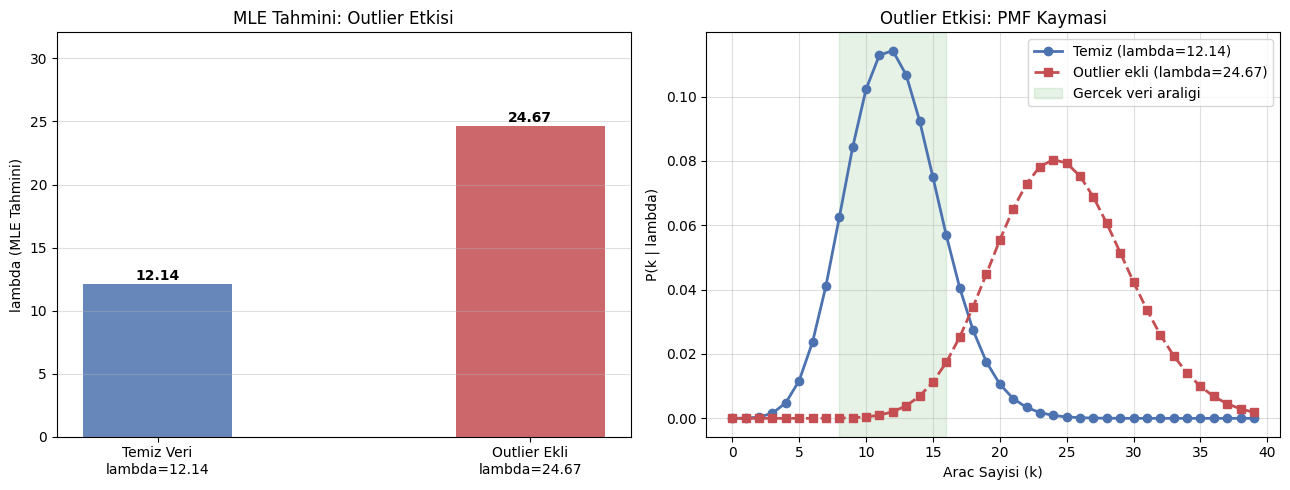

In [5]:
# Iki Poisson PMF karsilastirmasi
k_vals2     = np.arange(0, 40)
pmf_clean   = stats.poisson.pmf(k_vals2, mu=lambda_mle)
pmf_outlier = stats.poisson.pmf(k_vals2, mu=lambda_outlier)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Sol: lambda karsilastirmasi
labels = [f'Temiz Veri\nlambda={lambda_mle:.2f}',
          f'Outlier Ekli\nlambda={lambda_outlier:.2f}']
vals   = [lambda_mle, lambda_outlier]
colors = ['#4C72B0', '#C44E52']
axes[0].bar(labels, vals, color=colors, alpha=0.85, width=0.4)
axes[0].set_ylabel('lambda (MLE Tahmini)')
axes[0].set_title('MLE Tahmini: Outlier Etkisi')
axes[0].set_ylim(0, max(vals) * 1.3)
for i, v in enumerate(vals):
    axes[0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')
axes[0].grid(axis='y', alpha=0.4)

# Sag: PMF kayma grafigi
axes[1].plot(k_vals2, pmf_clean,   'o-',  color='#4C72B0',
             label=f'Temiz (lambda={lambda_mle:.2f})', lw=2)
axes[1].plot(k_vals2, pmf_outlier, 's--', color='#C44E52',
             label=f'Outlier ekli (lambda={lambda_outlier:.2f})', lw=2)
axes[1].axvspan(traffic_data.min(), traffic_data.max(),
                alpha=0.1, color='green', label='Gercek veri araligi')
axes[1].set_xlabel('Arac Sayisi (k)')
axes[1].set_ylabel('P(k | lambda)')
axes[1].set_title('Outlier Etkisi: PMF Kaymasi')
axes[1].legend()
axes[1].grid(alpha=0.4)

fig.tight_layout()
fig.savefig(REPORT_DIR / 'outlier_analizi.png', dpi=140)
plt.show()


### Outlier Analizi Yorumu (Soru 3)

**MLE'nin Outlier'a Hassasiyeti:**  
MLE tahmini λ = veri ortalaması olduğundan, tek bir `200`'lük aykırı değer λ'yı ~12.1'den ~24.7'ye yani yaklaşık **%103 yukarı** çekiyor. Bu, Poisson MLE'nin aykırı değerlere karşı **dirençsiz (non-robust)** olduğunu gösterir.

**Belediye Kararlarına Etkisi:**  
Şişirilmiş λ değeri kullanılırsa:
- Trafik yoğunluğu gerçeğin iki katı olarak tahmin edilir.
- Gereksiz yol genişletme veya kavşak iyileştirme kararları alınabilir.
- Bütçe israfı ve yanlış öncelik sıralaması ortaya çıkar.

**Çözüm Önerileri:**
1. Veri temizliği — IQR veya Z-score ile aykırı değer tespiti.
2. Robust istatistik — medyan tabanlı tahmin.
3. Bayesyen yaklaşım — güçlü prior ile aykırı değerlerin etkisi bastırılabilir.

---
## Rapor PDF Üretimi

In [6]:
def text_page(pdf, title, body, fontsize=11):
    fig = plt.figure(figsize=(8.27, 11.69))
    fig.text(0.08, 0.93, title, fontsize=15, fontweight='bold')
    fig.text(0.08, 0.87, body, fontsize=fontsize, va='top')
    pdf.savefig(fig); plt.close(fig)

def image_page(pdf, path, caption):
    import matplotlib.image as mpimg
    img = mpimg.imread(path)
    fig, ax = plt.subplots(figsize=(8.27, 11.69))
    ax.imshow(img); ax.axis('off')
    ax.set_title(caption, fontsize=12, pad=10)
    fig.tight_layout(); pdf.savefig(fig); plt.close(fig)

pdf_path = REPORT_DIR / 'Odev2_Rapor.pdf'
pct_sapma = (lambda_outlier / lambda_mle - 1) * 100

with PdfPages(pdf_path) as pdf:
    text_page(pdf, 'Odev 2 - MLE ile Akilli Sehir Planlamasi',
        f'YZM212 Makine Ogrenmesi  |  2. Laboratuvar Odevi\n\n'
        f'Yontem  : Maximum Likelihood Estimation (MLE)\n'
        f'Dagilim : Poisson\n\n'
        f'Temiz veri   -> lambda_MLE = {lambda_mle:.4f}\n'
        f'Outlier ekli -> lambda_MLE = {lambda_outlier:.4f}  (+{pct_sapma:.1f}% sapma)', fontsize=12)

    text_page(pdf, 'Bolum 1 - Teorik Turetme',
        'Likelihood:\n'
        '  L(lambda) = prod e^{-lambda} * lambda^{k_i} / k_i!\n\n'
        'Log-Likelihood:\n'
        '  l(lambda) = -n*lambda + (sum k_i)*ln(lambda) - sum ln(k_i!)\n\n'
        'Turev sifira esitleme:\n'
        '  dl/dlambda = -n + sum(k_i)/lambda = 0\n\n'
        '  => lambda_MLE = sum(k_i)/n = k_ort  (aritmetik ortalama)\n\n'
        'Poisson MLE tahmini veri ortalamasina esittir.', fontsize=11)

    image_page(pdf, REPORT_DIR / 'pmf_histogram.png',
               'Sekil 1 - Poisson PMF ve Gercek Veri Karsilastirmasi')
    image_page(pdf, REPORT_DIR / 'outlier_analizi.png',
               'Sekil 2 - Outlier (200) Etkisi: lambda Kaymasi ve PMF Sapmasi')

    text_page(pdf, 'Bolum 3-4 - Yorumlar ve Kaynakca',
        'Model Uyumu:\n'
        'PMF grafigi Poisson modelinin gercek veriyle iyi ortustugunu gosteriyor.\n'
        'Veri 8-16 araliginda yogunlasmis; model bu bicimi basariyla yakalamistir.\n\n'
        'Outlier Analizi:\n'
        'MLE = veri ortalamasi oldugu icin outlier dogrudan lambda yi etkiliyor.\n'
        f'Tek bir 200-araclik hata lambda yi {lambda_mle:.2f} -> {lambda_outlier:.2f} yukseltiyor.\n'
        'Bu belediyenin yanlis kapasite kararlari almasina yol acabilir.\n'
        'Cozum: veri temizligi veya robust tahmin yontemleri.\n\n'
        'Kaynakca:\n'
        'Bishop, C.M. (2006). Pattern Recognition and Machine Learning. Springer.\n'
        'scipy.optimize.minimize docs: https://docs.scipy.org/doc/scipy/', fontsize=11)

print(f'PDF rapor uretildi: {pdf_path}')


PDF rapor uretildi: ..\report\Odev2_Rapor.pdf
